In [10]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import accuracy_score

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.datasets import load_iris

In [11]:

# 1. Load data into a Pandas DataFrame for EDA
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)


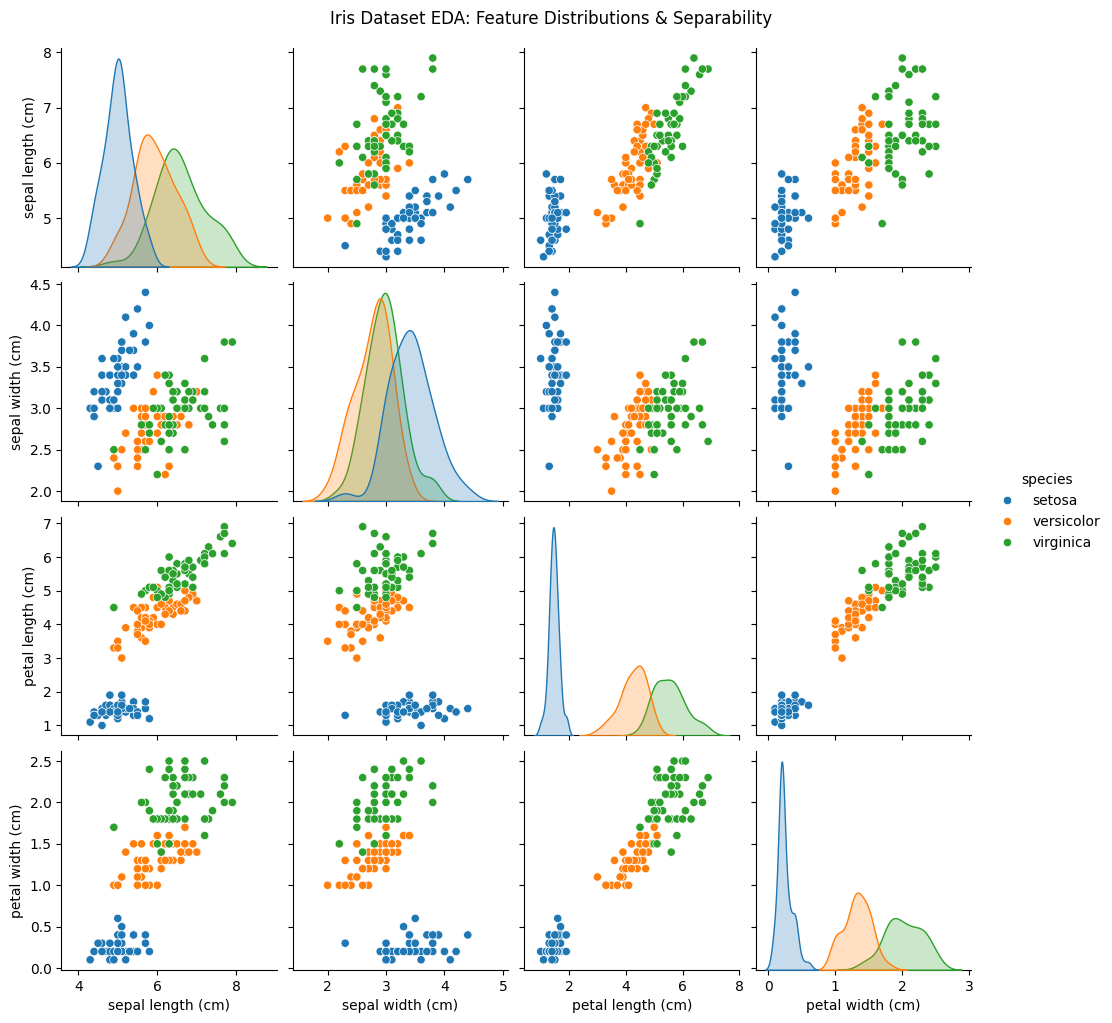

In [12]:

# 2. Generate a Pairplot to visualize distributions and separability
sns.pairplot(df, hue='species')
plt.suptitle("Iris Dataset EDA: Feature Distributions & Separability", y=1.02)
plt.show()

In [13]:

X, y = load_iris(return_X_y=True)
target_names = load_iris().target_names

# 2. Isolate training data from testing data (70/30 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)


In [14]:

lda = LinearDiscriminantAnalysis(n_components=2)

lda.fit(X_train, y_train)


,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",2
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


In [15]:

y_pred = lda.predict(X_test)
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")



Model Accuracy: 100.00%



In [17]:

# 5. Manual Input Inference
print("-" * 40)
print("MANUAL DATA INFERENCE")

# Input format: [sepal length, sepal width, petal length, petal width]
# Reshaping to (1, 4) because scikit-learn expects a 2D array for predictions
manual_input = np.array([1.1, 3.5, 1.4, 0.2]).reshape(1, -1)

# Predict the class and the underlying probabilities
predicted_class_index = lda.predict(manual_input)[0]
predicted_probabilities = lda.predict_proba(manual_input)[0]

print(f"Input Measurements: {manual_input[0]}")
print(f"Predicted Species: {target_names[predicted_class_index].upper()}")
print(f"Probability Scores: Setosa ({predicted_probabilities[0]:.4f}), "
      f"Versicolor ({predicted_probabilities[1]:.4f}), "
      f"Virginica ({predicted_probabilities[2]:.4f})")

----------------------------------------
MANUAL DATA INFERENCE
Input Measurements: [1.1 3.5 1.4 0.2]
Predicted Species: SETOSA
Probability Scores: Setosa (1.0000), Versicolor (0.0000), Virginica (0.0000)


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from matplotlib.colors import ListedColormap

In [2]:
iris = load_iris()
dataset = pd.DataFrame(columns=iris.feature_names, data=iris.data)
dataset['target'] = iris.target

X = dataset.iloc[:, 0:4].values
y = dataset.iloc[:, 4].values

In [3]:
sc = StandardScaler()
X_scaled = sc.fit_transform(X)

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_encoded, test_size=0.2, random_state=42)

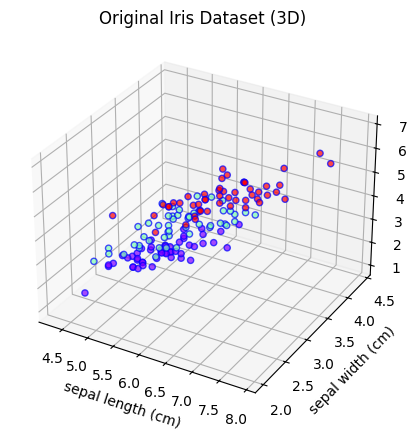

In [4]:
fig = plt.figure(figsize=(7,5))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:,0], X[:,1], X[:,2], c=y, cmap='rainbow', alpha=0.7, edgecolors='b')
ax.set_xlabel(iris.feature_names[0])
ax.set_ylabel(iris.feature_names[1])
ax.set_zlabel(iris.feature_names[2])
ax.set_title('Original Iris Dataset (3D)')
plt.show()

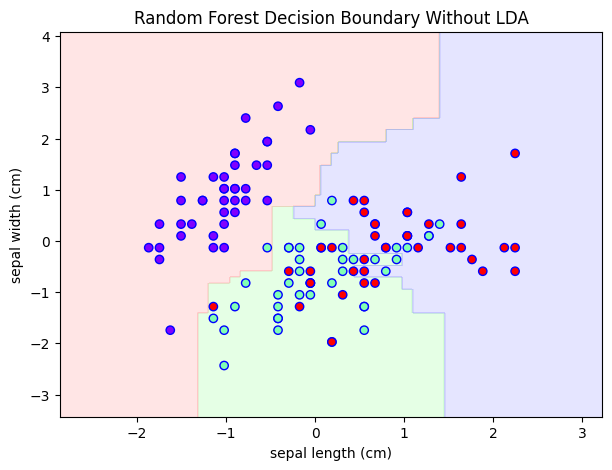

In [5]:
X_train_2D = X_train[:, :2]

rf_without_lda = RandomForestClassifier(max_depth=2, random_state=0)
rf_without_lda.fit(X_train_2D, y_train)

x_min, x_max = X_train_2D[:,0].min() - 1, X_train_2D[:,0].max() + 1
y_min, y_max = X_train_2D[:,1].min() - 1, X_train_2D[:,1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = rf_without_lda.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])

plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
plt.scatter(X_train_2D[:,0], X_train_2D[:,1], c=y_train, cmap='rainbow', edgecolors='b')
plt.xlabel(iris.feature_names[0])
plt.ylabel(iris.feature_names[1])
plt.title('Random Forest Decision Boundary Without LDA')
plt.show()

In [6]:
lda = LinearDiscriminantAnalysis(n_components=2)
X_train_lda = lda.fit_transform(X_train, y_train)
X_test_lda = lda.transform(X_test)

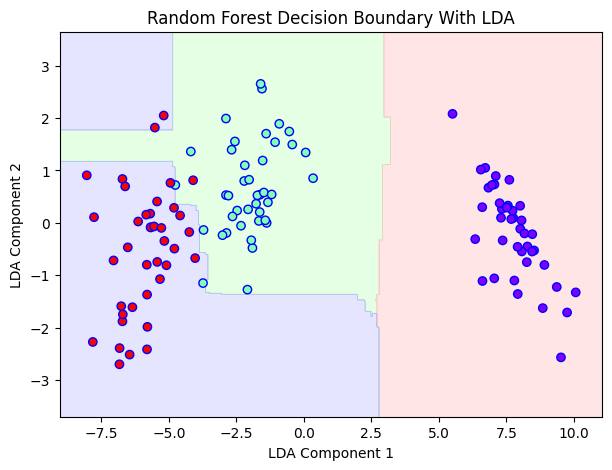

In [7]:
rf_with_lda = RandomForestClassifier(max_depth=2, random_state=0)
rf_with_lda.fit(X_train_lda, y_train)

x_min, x_max = X_train_lda[:,0].min() - 1, X_train_lda[:,0].max() + 1
y_min, y_max = X_train_lda[:,1].min() - 1, X_train_lda[:,1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = rf_with_lda.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(7,5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap_light)
plt.scatter(X_train_lda[:,0], X_train_lda[:,1], c=y_train, cmap='rainbow', edgecolors='b')
plt.xlabel('LDA Component 1')
plt.ylabel('LDA Component 2')
plt.title('Random Forest Decision Boundary With LDA')
plt.show()

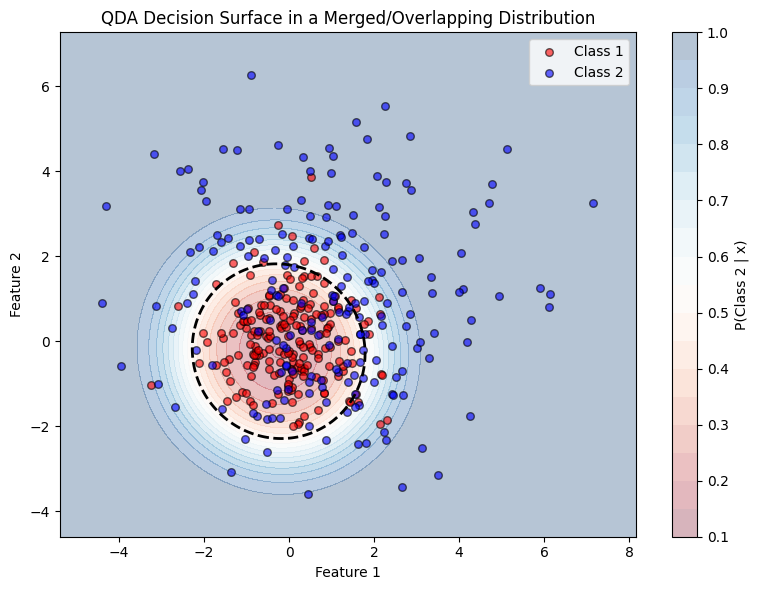

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis

# 1. Create heavily overlapping (merged) synthetic data
np.random.seed(42)
# Class 1: Centered at (0, 0) with small variance
X1 = np.random.randn(200, 2) * 1.0 + np.array([0.0, 0.0])
# Class 2: Centered at (1.0, 1.0) with larger variance (heavy overlap)
X2 = np.random.randn(200, 2) * 2.0 + np.array([1.0, 1.0])

X = np.vstack([X1, X2])
y = np.array([0] * 200 + [1] * 200)

# 2. Fit QDA
qda = QuadraticDiscriminantAnalysis(store_covariance=True)
qda.fit(X, y)

# 3. Create a mesh grid across the feature space
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))

# Evaluate Class 1 probability everywhere
grid_points = np.c_[xx.ravel(), yy.ravel()]
probs = qda.predict_proba(grid_points)[:, 1].reshape(xx.shape)

# 4. Plot
fig, ax = plt.subplots(figsize=(8, 6))

# Filled probability gradient (shows uncertainty in merged region)
contour_fill = ax.contourf(xx, yy, probs, levels=20, cmap="RdBu", alpha=0.3)
cbar = plt.colorbar(contour_fill)
cbar.set_label("P(Class 2 | x)")

# Hard decision boundary (P = 0.5)
ax.contour(xx, yy, probs, levels=[0.5], colors="black", linewidths=2, linestyles="--")

# Scatter points
ax.scatter(X1[:, 0], X1[:, 1], color="red", label="Class 1", alpha=0.6, edgecolors="k", s=30)
ax.scatter(X2[:, 0], X2[:, 1], color="blue", label="Class 2", alpha=0.6, edgecolors="k", s=30)

ax.set_title("QDA Decision Surface in a Merged/Overlapping Distribution")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.legend()
plt.tight_layout()
plt.show()

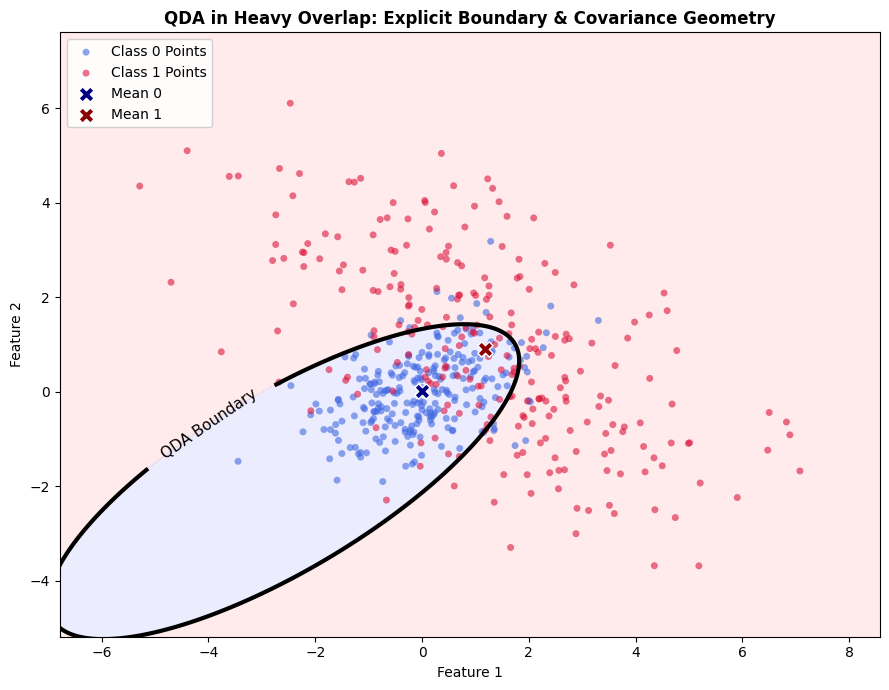

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from numpy.linalg import eigh

# 1. Synthesize heavily overlapping (merged) classes
np.random.seed(42)
# Class 0: tight cluster at origin
X0 = np.random.randn(250, 2) @ np.array([[1.0, 0.2], [0.2, 0.8]]) + np.array([0.0, 0.0])
# Class 1: wider cluster overlapping Class 0
X1 = np.random.randn(250, 2) @ np.array([[2.2, -0.6], [-0.6, 1.8]]) + np.array([1.2, 0.8])

X = np.vstack([X0, X1])
y = np.array([0] * len(X0) + [1] * len(X1))

# 2. Fit QDA
qda = QuadraticDiscriminantAnalysis(store_covariance=True)
qda.fit(X, y)

# 3. Create a wide mesh grid to capture curved quadratic branches
x_pad, y_pad = 2.0, 2.0
x_min, x_max = X[:, 0].min() - x_pad, X[:, 0].max() + x_pad
y_min, y_max = X[:, 1].min() - y_pad, X[:, 1].max() + y_pad
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                     np.linspace(y_min, y_max, 500))

grid = np.c_[xx.ravel(), yy.ravel()]

# Use the log-likelihood / discriminant score difference: delta_1(x) - delta_0(x) = 0
# This creates a sharp zero-crossing that avoids probability saturation
log_p = qda._decision_function(grid)
z = (log_p[:, 1] - log_p[:, 0]).reshape(xx.shape)

# 4. Plotting
fig, ax = plt.subplots(figsize=(9, 7))

# Shaded decision regions
ax.contourf(xx, yy, z > 0, alpha=0.15, cmap='bwr')

# PRIMARY FIX: High-contrast, thick solid boundary line at the zero-difference threshold
boundary = ax.contour(xx, yy, z, levels=[0], colors='black', linewidths=3.0, linestyles='-')
ax.clabel(boundary, fmt={0: 'QDA Boundary'}, inline=True, fontsize=11)

# Helper function to plot 2-sigma covariance ellipses
def plot_cov_ellipse(mean, cov, ax, color, label):
    vals, vecs = np.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * 2.0 * np.sqrt(vals)  # 2-sigma boundary (~95% coverage)
    ell = Ellipse(xy=mean, width=width, height=height, angle=theta,
                  edgecolor=color, facecolor='none', lw=2, ls='--', label=label)
    ax.add_patch(ell)

def plot_cov_ellipse(mean, cov, ax, color, label):
    # Fix: use np.linalg.eigh instead of np.eigh
    vals, vecs = np.linalg.eigh(cov)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
    width, height = 2 * 2.0 * np.sqrt(vals)  # 2-sigma boundary (~95% coverage)
    ell = Ellipse(xy=mean, width=width, height=height, angle=theta,
                  edgecolor=color, facecolor='none', lw=2, ls='--', label=label)
    ax.add_patch(ell)

# Scatter the observations
ax.scatter(X0[:, 0], X0[:, 1], c='royalblue', s=25, alpha=0.6, edgecolors='none', label='Class 0 Points')
ax.scatter(X1[:, 0], X1[:, 1], c='crimson', s=25, alpha=0.6, edgecolors='none', label='Class 1 Points')

# Mark centroids
ax.scatter(qda.means_[0][0], qda.means_[0][1], c='navy', s=120, marker='X', edgecolors='white', label='Mean 0')
ax.scatter(qda.means_[1][0], qda.means_[1][1], c='darkred', s=120, marker='X', edgecolors='white', label='Mean 1')

ax.set_title("QDA in Heavy Overlap: Explicit Boundary & Covariance Geometry", fontsize=12, fontweight='bold')
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_xlim(x_min + 0.5, x_max - 0.5)
ax.set_ylim(y_min + 0.5, y_max - 0.5)
ax.legend(loc='upper left', framealpha=0.9)
plt.tight_layout()
plt.show()